e:\ViT MLDC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Classes: ['Anthracnose', 'Bacterial_Canker', 'Die_Back', 'Gall_Mid', 'healthy']
Train: 2100  Val: 450  Test: 450
Extracting features...


100%|██████████| 450/450 [00:08<00:00, 51.87it/s]


Feature shapes: Train: (2100, 768) Val: (450, 768) Test: (450, 768)
Epoch 1/50 - Train Loss: 1.9975  Val Loss: 1.8599
Epoch 2/50 - Train Loss: 1.9515  Val Loss: 1.7863
Epoch 3/50 - Train Loss: 1.9323  Val Loss: 1.7500
Epoch 4/50 - Train Loss: 1.9185  Val Loss: 1.7265
Epoch 5/50 - Train Loss: 1.9108  Val Loss: 1.7098
Epoch 6/50 - Train Loss: 1.9063  Val Loss: 1.6994
Epoch 7/50 - Train Loss: 1.9015  Val Loss: 1.6937
Epoch 8/50 - Train Loss: 1.8956  Val Loss: 1.6866
Epoch 9/50 - Train Loss: 1.8939  Val Loss: 1.6803
Epoch 10/50 - Train Loss: 1.8939  Val Loss: 1.6760
Epoch 11/50 - Train Loss: 1.8904  Val Loss: 1.6716
Epoch 12/50 - Train Loss: 1.8900  Val Loss: 1.6687
Epoch 13/50 - Train Loss: 1.8866  Val Loss: 1.6675
Epoch 14/50 - Train Loss: 1.8863  Val Loss: 1.6658
Epoch 15/50 - Train Loss: 1.8842  Val Loss: 1.6636
Epoch 16/50 - Train Loss: 1.8833  Val Loss: 1.6606
Epoch 17/50 - Train Loss: 1.8846  Val Loss: 1.6592
Epoch 18/50 - Train Loss: 1.8804  Val Loss: 1.6599
Epoch 19/50 - Train Los

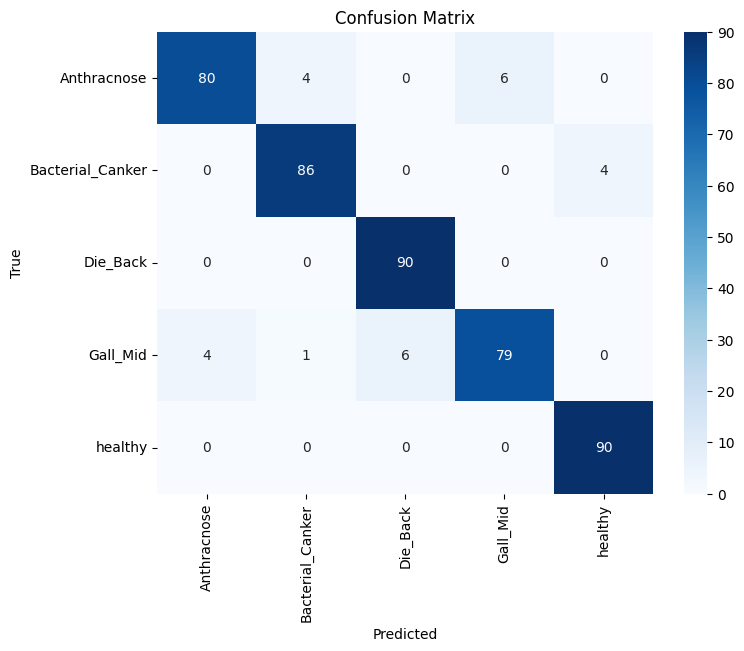

In [ ]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT MLDC\dataset2"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Dual Augmentation Transforms (tunable)
# =========================
# Hyperparameters you can tune:

ROTATION_DEGREES = 10
HFLIP_PROB = 0.5
VFLIP_PROB = 0.5
COLOR_JITTER1 = 0.2
COLOR_JITTER2 = 0.15
AFFINE_TRANSLATE = 0.1
RESIZEDCROP_SCALE = (0.9, 1)
DUAL_AUG1_PROB = 0.6
DUAL_AUG2_PROB = 0.4

# Base resize
train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]

# First augment: stronger random transforms
dual_aug1 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomRotation(ROTATION_DEGREES),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=COLOR_JITTER1, contrast=COLOR_JITTER1, saturation=COLOR_JITTER1),
        transforms.RandomAffine(degrees=0, translate=(AFFINE_TRANSLATE, AFFINE_TRANSLATE))
    ])
], p=DUAL_AUG1_PROB)

# Second augment: mild random crop / flip / jitter
dual_aug2 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomResizedCrop(IMG_SIZE, scale=RESIZEDCROP_SCALE),
        transforms.RandomVerticalFlip(p=VFLIP_PROB),
        transforms.ColorJitter(brightness=COLOR_JITTER2, contrast=COLOR_JITTER2, saturation=COLOR_JITTER2)
    ])
], p=DUAL_AUG2_PROB)

train_transforms = transforms.Compose(
    train_base + [dual_aug1, dual_aug2, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]
)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# Attention-Guided Mixup
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5, attention_maps=None):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats) * 2  # double the training data
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features=in_features, num_classes=num_classes, dropout_rate=0.4).to(device)

# =========================
# PolyLoss + Label Smoothing
# =========================
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = nn.functional.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = nn.functional.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

criterion = Poly1LossWithSmoothing(num_classes=num_classes, epsilon=0.5, label_smoothing=0.5)

# =========================
# Dataloaders
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                        torch.tensor(y_final, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# SAM Optimizer + CosineLR
# =========================
base_optimizer = torch.optim.Adam
rho = 0.05
lr = 1e-4
T_max = 50

optimizer = SAM(model_head.parameters(), base_optimizer, rho=rho, lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=T_max)

# =========================
# Training Loop
# =========================
EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
SAVE_DIR = r"E:\ViT MLDC\FINAL_NEW(5newHeads)\saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(SAVE_DIR, "ds2.pth")

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # second forward-backward step
        logits2 = model_head(xb)
        loss2 = criterion(logits2, yb)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# =========================
# Evaluation
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print(f"\nTest Metrics (Base + AGM + PolyLoss + LabelSmoothing + DualAug + SAM+CosineLR): "
      f"Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

train and test with same dataset

e:\ViT MLDC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Classes: ['Anthracnose', 'Bacterial_Canker', 'Die_Back', 'Gall_Mid', 'healthy']
Train: 2100  Val: 450  Test: 450
Extracting features...


100%|██████████| 450/450 [00:08<00:00, 51.70it/s]


Feature shapes: Train: (2100, 768) Val: (450, 768) Test: (450, 768)
Epoch 1/50 - Train Loss: 1.9975  Val Loss: 1.8599
Epoch 2/50 - Train Loss: 1.9515  Val Loss: 1.7863
Epoch 3/50 - Train Loss: 1.9323  Val Loss: 1.7500
Epoch 4/50 - Train Loss: 1.9185  Val Loss: 1.7265
Epoch 5/50 - Train Loss: 1.9108  Val Loss: 1.7098
Epoch 6/50 - Train Loss: 1.9063  Val Loss: 1.6994
Epoch 7/50 - Train Loss: 1.9015  Val Loss: 1.6937
Epoch 8/50 - Train Loss: 1.8956  Val Loss: 1.6866
Epoch 9/50 - Train Loss: 1.8939  Val Loss: 1.6803
Epoch 10/50 - Train Loss: 1.8939  Val Loss: 1.6760
Epoch 11/50 - Train Loss: 1.8904  Val Loss: 1.6716
Epoch 12/50 - Train Loss: 1.8900  Val Loss: 1.6687
Epoch 13/50 - Train Loss: 1.8866  Val Loss: 1.6675
Epoch 14/50 - Train Loss: 1.8863  Val Loss: 1.6658
Epoch 15/50 - Train Loss: 1.8842  Val Loss: 1.6636
Epoch 16/50 - Train Loss: 1.8833  Val Loss: 1.6606
Epoch 17/50 - Train Loss: 1.8846  Val Loss: 1.6592
Epoch 18/50 - Train Loss: 1.8804  Val Loss: 1.6599
Epoch 19/50 - Train Los

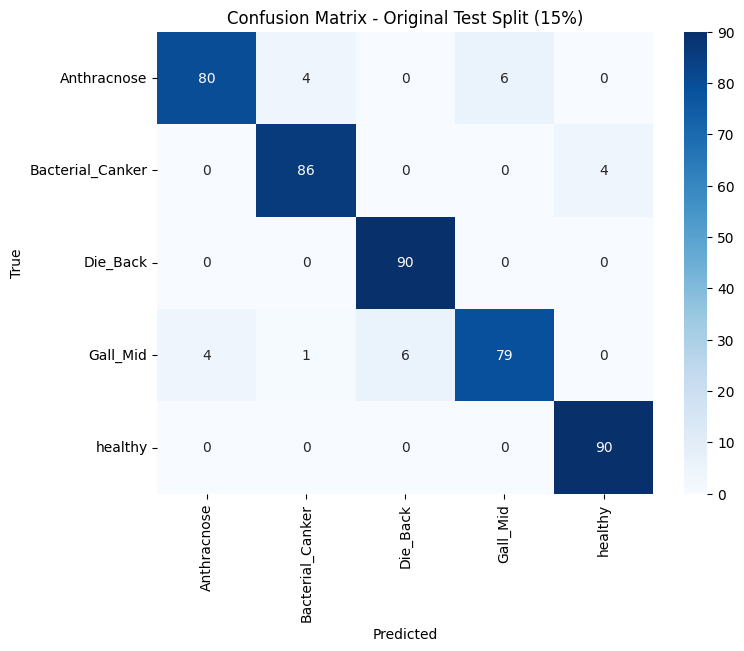

100%|██████████| 3000/3000 [00:56<00:00, 52.63it/s]



Full Dataset2 - Accuracy=0.9510, Precision=0.9512, Recall=0.9510, F1=0.9504


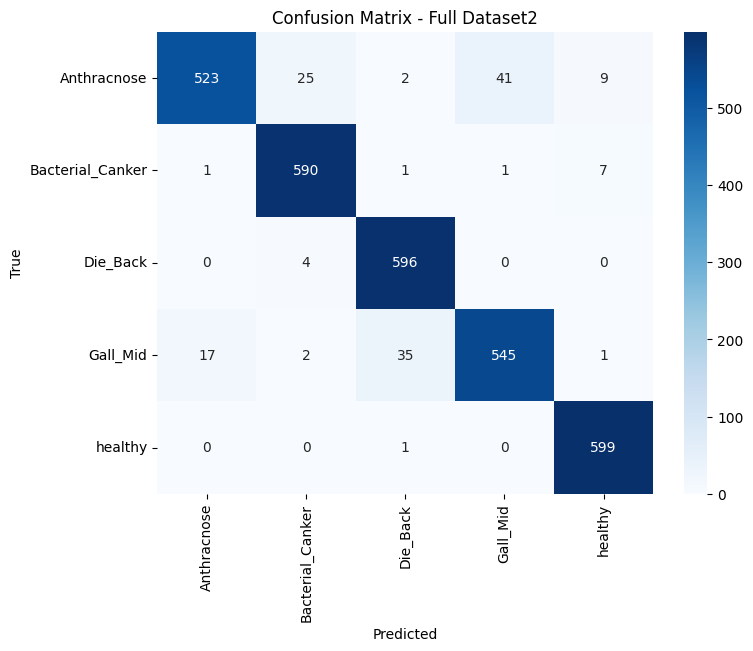

In [ ]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT MLDC\dataset2"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Dual Augmentation Transforms (tunable)
# =========================
ROTATION_DEGREES = 10
HFLIP_PROB = 0.5
VFLIP_PROB = 0.5
COLOR_JITTER1 = 0.2
COLOR_JITTER2 = 0.15
AFFINE_TRANSLATE = 0.1
RESIZEDCROP_SCALE = (0.9, 1)
DUAL_AUG1_PROB = 0.6
DUAL_AUG2_PROB = 0.4

# Base resize
train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]

# First augment: stronger random transforms
dual_aug1 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomRotation(ROTATION_DEGREES),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=COLOR_JITTER1, contrast=COLOR_JITTER1, saturation=COLOR_JITTER1),
        transforms.RandomAffine(degrees=0, translate=(AFFINE_TRANSLATE, AFFINE_TRANSLATE))
    ])
], p=DUAL_AUG1_PROB)

# Second augment: mild random crop / flip / jitter
dual_aug2 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomResizedCrop(IMG_SIZE, scale=RESIZEDCROP_SCALE),
        transforms.RandomVerticalFlip(p=VFLIP_PROB),
        transforms.ColorJitter(brightness=COLOR_JITTER2, contrast=COLOR_JITTER2, saturation=COLOR_JITTER2)
    ])
], p=DUAL_AUG2_PROB)

train_transforms = transforms.Compose(
    train_base + [dual_aug1, dual_aug2, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]
)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# Attention-Guided Mixup
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5, attention_maps=None):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats) * 2
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features=in_features, num_classes=num_classes, dropout_rate=0.4).to(device)

# =========================
# PolyLoss + Label Smoothing
# =========================
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = nn.functional.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = nn.functional.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

criterion = Poly1LossWithSmoothing(num_classes=num_classes, epsilon=0.5, label_smoothing=0.5)

# =========================
# Dataloaders
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                        torch.tensor(y_final, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# SAM Optimizer + CosineLR
# =========================
base_optimizer = torch.optim.Adam
rho = 0.05
lr = 1e-4
T_max = 50

optimizer = SAM(model_head.parameters(), base_optimizer, rho=rho, lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=T_max)

# =========================
# Training Loop (Cleaned Best Model Saving)
# =========================
EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
SAVE_DIR = r"E:\ViT MLDC\FINAL_NEW(5newHeads)\saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(SAVE_DIR, "ds2.pth")

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # second forward-backward step
        logits2 = model_head(xb)
        loss2 = criterion(logits2, yb)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Save best model only
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nTraining finished. Best model saved at {best_model_path} with Val Loss={best_val_loss:.4f}")

# =========================
# Evaluation on Test Split
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

def evaluate(loader, title="Evaluation"):
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            outputs = model_head(xb)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    print(f"\n{title} - Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

# Evaluate on original test split
evaluate(test_loader, title="Original Test Split (15%)")

# =========================
# Evaluation on Full Dataset2
# =========================
full_image_paths, full_labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    full_image_paths.extend(imgs)
    full_labels.extend([lbl]*len(imgs))

full_labels_encoded = le.transform(full_labels)
X_full_feats = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(full_image_paths)])
full_loader = DataLoader(
    TensorDataset(torch.tensor(X_full_feats, dtype=torch.float32),
                  torch.tensor(full_labels_encoded, dtype=torch.long)),
    batch_size=64,
    shuffle=False
)

evaluate(full_loader, title="Full Dataset2")